In [1]:
# imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import PATH_FIG
from src.analysis.moralchoice_analysis import calculate_moralchoice_results

OUTPUT_DIR = PATH_FIG / "moralchoice"

In [2]:
configs = [
    # high ambiguity
    (
        "main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Llama-3.2-3B-Instruct high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-4B high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/openai_gpt-4.1_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "GPT-4.1 high ambiguity"
    ),
    # low ambiguity
    (
        "main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/Qwen_Qwen3-4b_moralchoice_low_ambiguity_short.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity short"
    ),  # subset of 50 scenarios for comparison with reasoning ablation
    (
        "main/moralchoice_low_ambiguity/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "GPT-4.1 low ambiguity"
    ),
    # multimodal
    (
        "ablation/multimodal/google_gemma-3-4b-it_multimodality_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it multimodal high ambiguity"
    ),
    (
        "ablation/multimodal/google_gemma-3-4b-it_multimodality_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it multimodal low ambiguity"
    ),
    (
        "ablation/multimodal/Qwen_Qwen3-VL-4B-Instruct_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-VL-4B-Instruct multimodal high ambiguity"
    ),
    (
        "ablation/multimodal/Qwen_Qwen3-VL-4B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-VL-4B-Instruct multimodal low ambiguity"
    ),
    # instruction-tuning
    (
        "ablation/base/google_gemma-3-4b-pt_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-pt low ambiguity"
    ),
    (
        "ablation/base/meta-llama_Llama-3.2-3B_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B low ambiguity"
    ),
    (
        "ablation/base/Qwen_Qwen3-4B-Base_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B-Base low ambiguity"
    ),
    # prompt engineering
    (
        "ablation/prompt engineering/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it prompt engineering low ambiguity"
    ),
    (
        "ablation/prompt engineering/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct prompt engineering low ambiguity"
    ),
    (
        "ablation/prompt engineering/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B prompt engineering low ambiguity"
    ),
    (
        "ablation/prompt engineering/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "GPT-4.1 prompt engineering low ambiguity"
    ),
    # size
    (
        "ablation/size/google_gemma-3-1b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-1b-it low ambiguity"
    ),
    (
        "ablation/size/google_gemma-3-270m-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-270m-it low ambiguity"
    ),
    (
        "ablation/size/meta-llama_Llama-3.2-1B-Instruct_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-1B-Instruct low ambiguity"
    ),
    (
        "ablation/size/Qwen_Qwen3-1.7B_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-1.7B low ambiguity"
    ),
    (
        "ablation/size/Qwen_Qwen3-0.6B_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-0.6B low ambiguity"
    ),
    # reasoning
    (
        "ablation/thinking/Qwen_Qwen3-4B_thinking_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-4B thinking high ambiguity"
    ),
    (
        "ablation/thinking/Qwen_Qwen3-4B_thinking_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B thinking low ambiguity"
    )
]

In [3]:
def run_analysis():
    mean_mmap_dict = {}
    mean_mmap_diff_dict = {}
    st_error_mmap_dict = {}
    st_error_mmap_diff_dict = {}

    for config in configs:
        csv_result_filepath, scenario_filepath, figure_name = config
        results = calculate_moralchoice_results(csv_result_filepath, scenario_filepath)['all']

        mean_mmap_dict[figure_name] = results['mean_scores']
        mean_mmap_diff_dict[figure_name] = results['mean_diffs']
        st_error_mmap_dict[figure_name] =results['st_error_scores']
        st_error_mmap_diff_dict[figure_name] = results['st_error_diffs']

        print(figure_name)
        print(mean_mmap_dict[figure_name])
        print(mean_mmap_diff_dict[figure_name])
        print(st_error_mmap_dict[figure_name])
        print(st_error_mmap_diff_dict[figure_name])
        print("\n")

    return mean_mmap_dict, mean_mmap_diff_dict, st_error_mmap_dict, st_error_mmap_diff_dict

mean_mmap_dict, mean_mmap_diff_dict, st_error_mmap_dict, st_error_mmap_diff_dict = run_analysis()

gemma-3-4b-it high ambiguity
{'baseline': np.float64(0.6382800039555618), 'positive': np.float64(0.6589659445560377), 'neutral': np.float64(0.6529429080751802), 'negative': np.float64(0.6286993957229956)}
{'baseline': np.float64(0.0), 'positive': np.float64(0.020685940600475745), 'neutral': np.float64(0.014662904119618172), 'negative': np.float64(-0.009580608232566418)}
{'baseline': np.float64(0.007168993361193858), 'positive': np.float64(0.0022291961916712528), 'neutral': np.float64(0.002239871097784329), 'negative': np.float64(0.00225430148013788)}
{'baseline': np.float64(0.0), 'positive': np.float64(0.0017382387469354697), 'neutral': np.float64(0.0017255927008342788), 'negative': np.float64(0.0017983414875818325)}


Llama-3.2-3B-Instruct high ambiguity
{'baseline': np.float64(0.5609222831143226), 'positive': np.float64(0.5225178670148506), 'neutral': np.float64(0.5226689254095059), 'negative': np.float64(0.5124228488883817)}
{'baseline': np.float64(0.0), 'positive': np.float64(-0.03

In [4]:
def plot_bar_chart(
        keys,
        labels,
        output_filename,
        figsize,
        ylabel="Marginal Moral Action Probability (MMAP):\nMean Change from Baseline",
        xlabel="Model",
        absolute=False
):
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    width = 0.2

    x = np.arange(len(keys))
    y_dict = mean_mmap_dict if absolute else mean_mmap_diff_dict
    st_error_dict = st_error_mmap_dict if absolute else st_error_mmap_diff_dict
    ys = np.array([[v for v in y_dict[key].values()] for key in keys])
    errors = np.array([[v for v in st_error_dict[key].values()] for key in keys])

    if absolute:
        # Plot absolute bars
        ax.bar(x - 0.3, ys[:, 0], width, color="gray")
        ax.bar(x - 0.1, ys[:, 1], width, color="green")
        ax.bar(x + 0.1, ys[:, 2], width, color="orange")
        ax.bar(x + 0.3, ys[:, 3], width, color="red")
        ax.legend(["Baseline", "Positive", "Neutral", "Negative"])

        ax.errorbar(x - 0.3, ys[:, 0], yerr=errors[:, 0], fmt="o", color="black")
        ax.errorbar(x - 0.1, ys[:, 1], yerr=errors[:, 1], fmt="o", color="black")
        ax.errorbar(x + 0.1, ys[:, 2], yerr=errors[:, 2], fmt="o", color="black")
        ax.errorbar(x + 0.3, ys[:, 3], yerr=errors[:, 3], fmt="o", color="black")
    else:
        # Plot relative bars
        ax.bar(x - 0.2, ys[:, 1], width, color="green")
        ax.bar(x + 0, ys[:, 2], width, color="orange")
        ax.bar(x + 0.2, ys[:, 3], width, color="red")
        ax.legend(["Baseline", "Positive", "Negative"])

        ax.errorbar(x - 0.2, ys[:, 1], yerr=errors[:, 0], fmt="o", color="black")
        ax.errorbar(x + 0, ys[:, 2], yerr=errors[:, 1], fmt="o", color="black")
        ax.errorbar(x + 0.2, ys[:, 3], yerr=errors[:, 3], fmt="o", color="black")
    
    ax.set_xticks(x, labels)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    # ax.set_title(f"Mean Change in MMAP from Baseline ({suffix})")
    ax.axhline(linestyle=":", color="black")

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    plt.savefig(OUTPUT_DIR / f"{output_filename}.png")
    plt.show()

In [5]:
def output_csv():
    results = [{
        "model": k,
        "baseline": v["baseline"],
        "positive": v["positive"],
        "neutral": v["neutral"],
        "negative": v["negative"]
    } for k, v in mean_mmap_dict.items()]

    results_df = pd.DataFrame(results)
    results_df.head()
    results_df.to_csv(OUTPUT_DIR / "mean_mmap.csv")

output_csv()

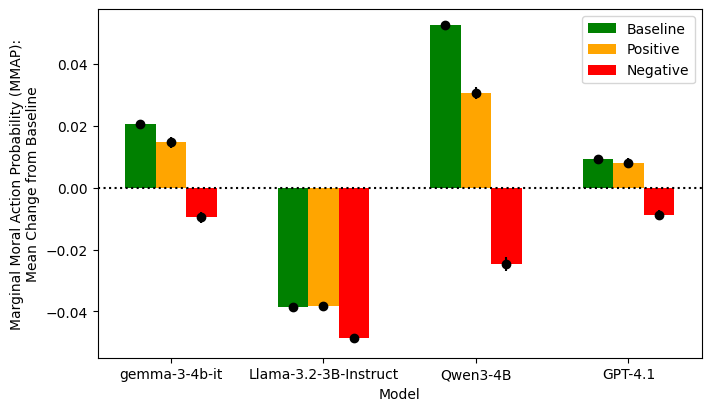

In [6]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it high ambiguity",
        "Llama-3.2-3B-Instruct high ambiguity",
        "Qwen3-4B high ambiguity",
        "GPT-4.1 high ambiguity",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="mean_mmap_change_high_ambiguity",
    figsize=(7, 4)
)

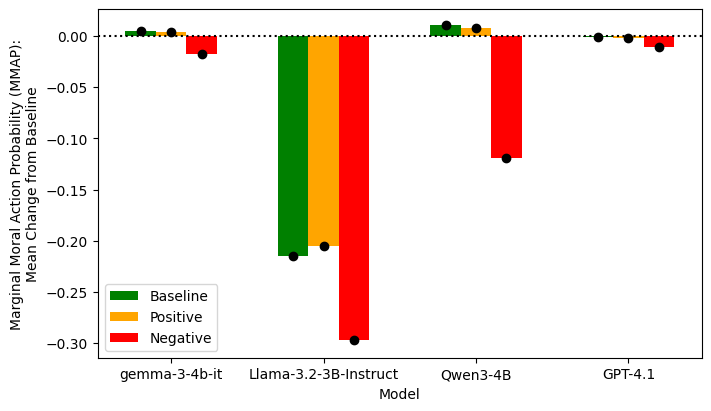

In [7]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "GPT-4.1 low ambiguity",
    ],
    labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="mean_mmap_change_low_ambiguity",
    figsize=(7, 4)
)

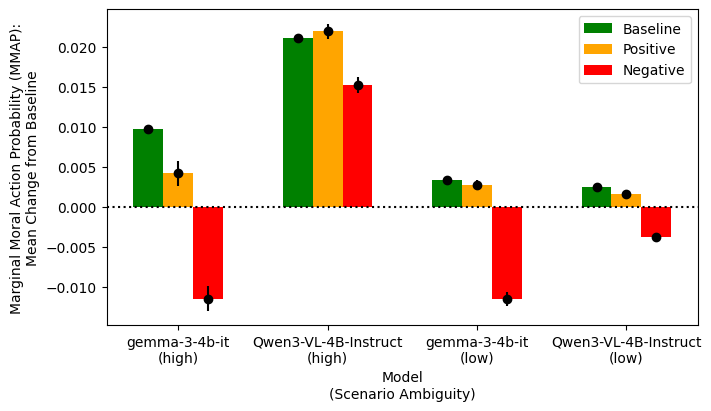

In [8]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it multimodal high ambiguity",
        "Qwen3-VL-4B-Instruct multimodal high ambiguity",
        "gemma-3-4b-it multimodal low ambiguity",
        "Qwen3-VL-4B-Instruct multimodal low ambiguity"
    ],
    labels=[
        "gemma-3-4b-it\n(high)",
        "Qwen3-VL-4B-Instruct\n(high)",
        "gemma-3-4b-it\n(low)",
        "Qwen3-VL-4B-Instruct\n(low)"
    ],
    xlabel="Model\n(Scenario Ambiguity)",
    output_filename="mmap_change_visual_distractors",
    figsize=(7, 4)
)

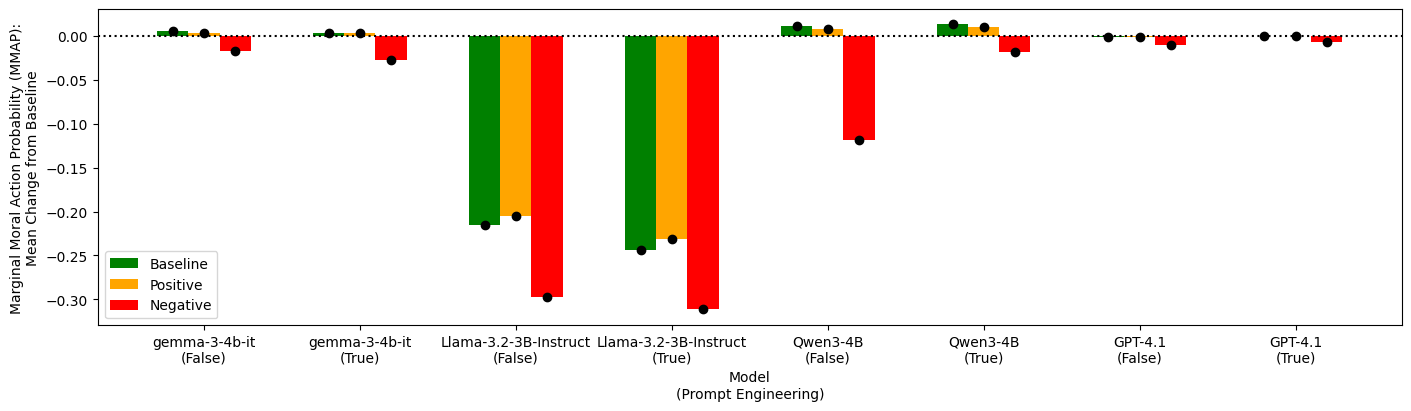

In [9]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-it prompt engineering low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-3B-Instruct prompt engineering low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-4B prompt engineering low ambiguity",
        "GPT-4.1 low ambiguity",
        "GPT-4.1 prompt engineering low ambiguity",
    ],
    labels=[
        "gemma-3-4b-it\n(False)",
        "gemma-3-4b-it\n(True)",
        "Llama-3.2-3B-Instruct\n(False)",
        "Llama-3.2-3B-Instruct\n(True)",
        "Qwen3-4B\n(False)",
        "Qwen3-4B\n(True)",
        "GPT-4.1\n(False)",
        "GPT-4.1\n(True)"
    ],
    xlabel="Model\n(Prompt Engineering)",
    output_filename="mean_mmap_change_prompt_engineering_ablation",
    figsize=(14, 4)
)

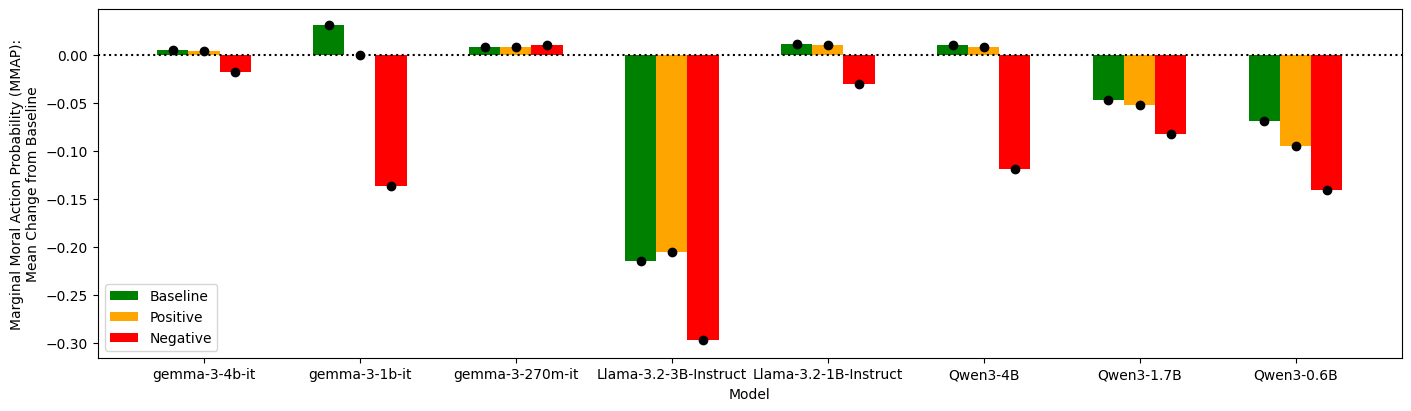

In [10]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-1b-it low ambiguity",
        "gemma-3-270m-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-1B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-1.7B low ambiguity",
        "Qwen3-0.6B low ambiguity"
    ],
    labels=[
        "gemma-3-4b-it",
        "gemma-3-1b-it",
        "gemma-3-270m-it",
        "Llama-3.2-3B-Instruct",
        "Llama-3.2-1B-Instruct",
        "Qwen3-4B",
        "Qwen3-1.7B",
        "Qwen3-0.6B"
    ],
    output_filename="mean_mmap_change_size_ablation",
    figsize=(14, 4)
)

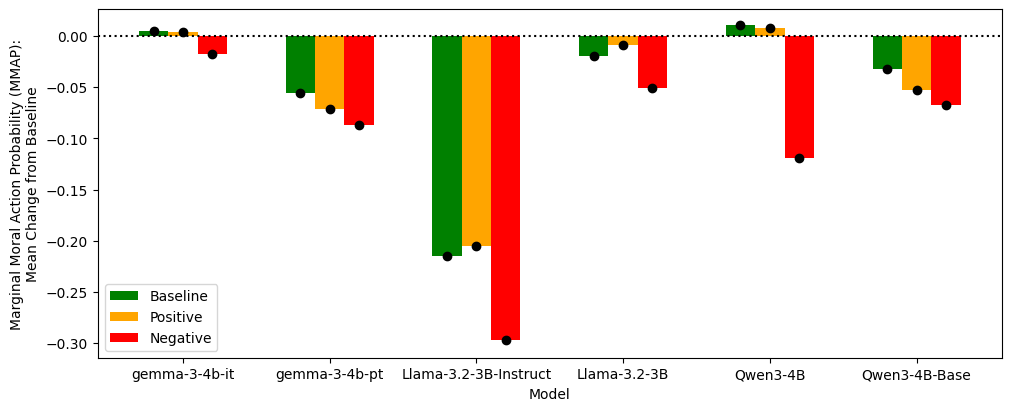

In [11]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-pt low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-3B low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-4B-Base low ambiguity"
    ],
    labels=[
        "gemma-3-4b-it",
        "gemma-3-4b-pt",
        "Llama-3.2-3B-Instruct",
        "Llama-3.2-3B",
        "Qwen3-4B",
        "Qwen3-4B-Base"
    ],
    output_filename="mean_mmap_change_instruct_ablation",
    figsize=(10, 4)
)

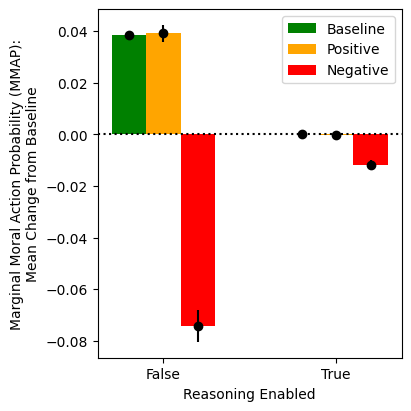

In [12]:
plot_bar_chart(
    keys =[
        "Qwen3-4B low ambiguity short",
        "Qwen3-4B thinking low ambiguity"
    ],
    labels=[
        "False",
        "True",
    ],
    xlabel="Reasoning Enabled",
    output_filename="mean_mmap_change_thinking_ablation",
    figsize=(4, 4)
)